# Denoising score matching

In [1]:
import torch
import torch.nn as nn
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt

## Datos de entrenamiento

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

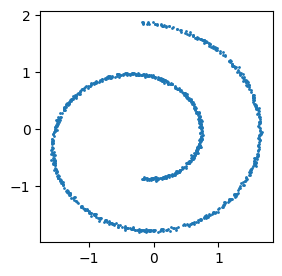

In [3]:
samples = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Red neuronal

In [4]:
class ScoreNetwork(nn.Module):

    def __init__(self, data_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(data_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x):
        return self.mlp(x)

## Entrenamiento

In [5]:
def train_model(net, optimizer, batch_fn, n_iters, sigma=0.1):

    for _ in range(n_iters):

        x = batch_fn()  # [batch_size, data_dim].
        epsilon = torch.randn_like(x)
        x_bar = x + sigma * epsilon

        difference = net(x_bar) + epsilon / sigma  # [batch_size, data_dim].
        fisher_div = 1/2 * torch.linalg.norm(difference, dim=-1) ** 2
        loss = fisher_div.mean(dim=0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [6]:
net = ScoreNetwork(data_dim=2)
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4)

train_model(net, optimizer, get_batch, n_iters=5000)

## Generación

In [7]:
def langevin_sampling(net, n_samples, step_size=0.01, n_steps=2000):

    with torch.no_grad():
        x = torch.rand((n_samples, 2))
        for _ in range(n_steps):
            epsilon = torch.randn_like(x)
            x = x + step_size * net(x) + (2 * step_size) ** 0.5 * epsilon
        return x

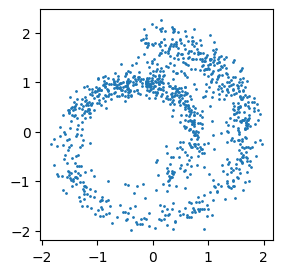

In [8]:
samples = langevin_sampling(net, 1000)

plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()